In [1]:
import warnings
warnings.filterwarnings("ignore")

# Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date and Time
from datetime import datetime

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder
)

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.impute import SimpleImputer

# Models
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Random Seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# Main Training Dataset
public_trip = pd.read_csv("public_trip_data.csv")

# Private Test Dataset
private_trip = pd.read_csv("private_trip_data.csv")

# Event Logs
public_event_log = pd.read_csv("public_trip_event_log.csv")
private_event_log = pd.read_csv("private_trip_event_log.csv")

# Event Attributes
public_event_attr = pd.read_csv("public_trip_event_attributes.csv")
private_event_attr = pd.read_csv("private_trip_event_attributes.csv")

# Sample Submission
sample_submission = pd.read_csv("sample_submission.csv")

In [3]:
print("\nDataset Shapes\n")

print(f"Public Trip Data          : {public_trip.shape}")
print(f"Private Trip Data         : {private_trip.shape}")
print(f"Public Event Log          : {public_event_log.shape}")
print(f"Private Event Log         : {private_event_log.shape}")
print(f"Public Event Attributes   : {public_event_attr.shape}")
print(f"Private Event Attributes  : {private_event_attr.shape}")
print(f"Sample Submission         : {sample_submission.shape}")


Dataset Shapes

Public Trip Data          : (65289, 20)
Private Trip Data         : (21764, 13)
Public Event Log          : (671547, 4)
Private Event Log         : (223819, 4)
Public Event Attributes   : (65289, 19)
Private Event Attributes  : (21764, 18)
Sample Submission         : (21764, 2)


In [4]:
print("\nPublic Trip Data")
display(public_trip.head())

print("\nPublic Event Log")
display(public_event_log.head())

print("\nPublic Event Attributes")
display(public_event_attr.head())


Public Trip Data


,TripID,DepartureLocationCountry,DepartureLocationCity,ArrivalLocationCountry,ArrivalLocationCity,ShippingType,ShippingTypeDescription,Purpose,OutOfPolicy,EntitiyCode,EmployeeNumber,BusinessUnit,HotelNights,NetCosts,Departure_CO2e,Return_CO2e,Hotel_CO2e,Spend_CO2e,TotalCO2e,HighCarbon
0,1,CN,Beijing,IN,New Delhi,12,Business Class Flight,Customer Visit,No,9000,M1000-M5008,Services,1,900,1565.121857,1565.121857,58.9,1472.279257,3189.143714,0
1,3,US,New York,MX,Mexico City,11,First Class Flight,Customer Visit,Yes,6000,M1000-M5030,Sales,2,3600,743.295848,743.295848,38.6,2921.504761,1525.191696,0
2,6,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Conference/Exhibition,No,9000,M1000-M5069,Services,1,450,1053.713528,1053.713528,51.4,743.646219,2158.827056,0
3,7,DE,Berlin,FR,Paris,12,Business Class Flight,Customer Visit,No,10000,M1000-M5095,Executive Management,1,3450,196.262703,196.262703,6.7,3343.160260,399.225407,0
4,8,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Internal Business Trip,No,7000,M1000-M5097,Marketing,2,1500,1053.713528,1053.713528,102.8,2478.820729,2210.227056,0



Public Event Log


,TripID,StepOrder,EventName,EventTimestamp
0,1,1,Book Mode of Transportation,03/21/2024 23:36:20
1,1,2,Book Lodging,03/22/2024 09:16:16
2,1,3,Submit Travel Request,03/22/2024 12:15:19
3,1,4,Travel Request Approved,03/23/2024 08:12:58
4,1,5,Receive Confirmation,03/23/2024 23:42:47



Public Event Attributes


,TripID,EmployeeNumber,TravelRequestID,ExpenseRequestID,ExpenseDenialReason,ExpenseReimbursementReason,ExpenseReimbursementAmount,ReasonForTransportCancellation,NewTransportSelection,ReasonForNewTransport,NewHotelSelection,ReasonForNewHotel,NewModeOfTransportation,TransportationPriceDifference,ReasonForTransportationChange,ReasonForDelay,ExtensionLength,DaysPreapproved,ProcessCode
0,1,M1000-M5008,TR000001,EXP000001,NaN,Policy exception approved,267.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,V1
1,3,M1000-M5030,TR000003,EXP000003,NaN,Partial reimbursement,526.90,Personal emergency,Rebooked flight,Better schedule,NaN,NaN,Updated First Class Flight,140.62,Time constraints,NaN,NaN,2,V1
2,6,M1000-M5069,TR000006,EXP000006,NaN,Policy exception approved,487.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Weather delay,NaN,1,V1
3,7,M1000-M5095,TR000007,EXP000007,NaN,Policy exception approved,511.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,V1
4,8,M1000-M5097,TR000008,EXP000008,NaN,Standard travel reimbursement,452.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mechanical issue,NaN,2,V20


In [5]:
print(public_trip["HighCarbon"].value_counts())

print("\nPercentage\n")

print(public_trip["HighCarbon"].value_counts(normalize=True) * 100)

HighCarbon
0    48963
1    16326
Name: count, dtype: int64

Percentage

HighCarbon
0    74.994256
1    25.005744
Name: proportion, dtype: float64


In [6]:
print("Public Trip Columns")

for col in public_trip.columns:
    print(col)
print(public_trip.columns.tolist())

Public Trip Columns
TripID
DepartureLocationCountry
DepartureLocationCity
ArrivalLocationCountry
ArrivalLocationCity
ShippingType
ShippingTypeDescription
Purpose
OutOfPolicy
EntitiyCode
EmployeeNumber
BusinessUnit
HotelNights
NetCosts
Departure_CO2e
Return_CO2e
Hotel_CO2e
Spend_CO2e
TotalCO2e
HighCarbon
['TripID', 'DepartureLocationCountry', 'DepartureLocationCity', 'ArrivalLocationCountry', 'ArrivalLocationCity', 'ShippingType', 'ShippingTypeDescription', 'Purpose', 'OutOfPolicy', 'EntitiyCode', 'EmployeeNumber', 'BusinessUnit', 'HotelNights', 'NetCosts', 'Departure_CO2e', 'Return_CO2e', 'Hotel_CO2e', 'Spend_CO2e', 'TotalCO2e', 'HighCarbon']


In [7]:
print("Public Event Log Columns")

for col in public_event_log.columns:
    print(col)
print(public_event_log.columns.tolist())

Public Event Log Columns
TripID
StepOrder
EventName
EventTimestamp
['TripID', 'StepOrder', 'EventName', 'EventTimestamp']


In [8]:
print("Public Event Attribute Columns")

for col in public_event_attr.columns:
    print(col)
print(public_event_attr.columns.tolist())

Public Event Attribute Columns
TripID
EmployeeNumber
TravelRequestID
ExpenseRequestID
ExpenseDenialReason
ExpenseReimbursementReason
ExpenseReimbursementAmount
ReasonForTransportCancellation
NewTransportSelection
ReasonForNewTransport
NewHotelSelection
ReasonForNewHotel
NewModeOfTransportation
TransportationPriceDifference
ReasonForTransportationChange
ReasonForDelay
ExtensionLength
DaysPreapproved
ProcessCode
['TripID', 'EmployeeNumber', 'TravelRequestID', 'ExpenseRequestID', 'ExpenseDenialReason', 'ExpenseReimbursementReason', 'ExpenseReimbursementAmount', 'ReasonForTransportCancellation', 'NewTransportSelection', 'ReasonForNewTransport', 'NewHotelSelection', 'ReasonForNewHotel', 'NewModeOfTransportation', 'TransportationPriceDifference', 'ReasonForTransportationChange', 'ReasonForDelay', 'ExtensionLength', 'DaysPreapproved', 'ProcessCode']


In [9]:
# Create copies to preserve original datasets
train_df = public_trip.copy()
test_df = private_trip.copy()

print("Original Train Shape :", train_df.shape)
print("Original Test Shape  :", test_df.shape)

Original Train Shape : (65289, 20)
Original Test Shape  : (21764, 13)


In [10]:
# Target Variable
y = train_df["HighCarbon"]

print("Target Shape :", y.shape)

Target Shape : (65289,)


In [11]:
train_df.drop(columns=["HighCarbon"], inplace=True)

In [12]:
leakage_features = [
    "Departure_CO2e",
    "Return_CO2e",
    "Hotel_CO2e",
    "Spend_CO2e",
    "TotalCO2e"
]

train_df.drop(columns=leakage_features, inplace=True)

print("Leakage columns removed.")

Leakage columns removed.


In [13]:
print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

Train Shape : (65289, 14)
Test Shape  : (21764, 13)


In [14]:
print("Missing Values (Train)")

missing_train = train_df.isnull().sum().sort_values(ascending=False)

print(missing_train[missing_train > 0])

Missing Values (Train)
Series([], dtype: int64)


In [15]:
print("Missing Values (Test)")

missing_test = test_df.isnull().sum().sort_values(ascending=False)

print(missing_test[missing_test > 0])

Missing Values (Test)
Series([], dtype: int64)


In [16]:
print("Duplicate TripID Check")

print("Train :", train_df["TripID"].duplicated().sum())
print("Test  :", test_df["TripID"].duplicated().sum())

Duplicate TripID Check
Train : 0
Test  : 0


In [17]:
print("Duplicate Event Rows")

print(public_event_log.duplicated().sum())

Duplicate Event Rows
0


In [18]:
print("Duplicate Attribute Rows")

print(public_event_attr.duplicated().sum())

Duplicate Attribute Rows
0


In [19]:
public_event_log["EventTimestamp"] = pd.to_datetime(
    public_event_log["EventTimestamp"]
)

private_event_log["EventTimestamp"] = pd.to_datetime(
    private_event_log["EventTimestamp"]
)

print("Timestamp converted successfully.")

Timestamp converted successfully.


In [20]:
event_features_train = public_event_log.groupby("TripID").agg(
    EventCount=("EventName", "count"),
    UniqueEvents=("EventName", "nunique"),
    MaxStep=("StepOrder", "max"),
    FirstEvent=("EventTimestamp", "min"),
    LastEvent=("EventTimestamp", "max")
).reset_index()

event_features_test = private_event_log.groupby("TripID").agg(
    EventCount=("EventName", "count"),
    UniqueEvents=("EventName", "nunique"),
    MaxStep=("StepOrder", "max"),
    FirstEvent=("EventTimestamp", "min"),
    LastEvent=("EventTimestamp", "max")
).reset_index()

In [21]:
event_features_train["ProcessDurationHours"] = (
    event_features_train["LastEvent"] -
    event_features_train["FirstEvent"]
).dt.total_seconds() / 3600

event_features_test["ProcessDurationHours"] = (
    event_features_test["LastEvent"] -
    event_features_test["FirstEvent"]
).dt.total_seconds() / 3600

In [22]:
event_features_train["BookingMonth"] = (
    event_features_train["FirstEvent"].dt.month
)

event_features_test["BookingMonth"] = (
    event_features_test["FirstEvent"].dt.month
)

In [23]:
event_features_train["BookingWeekday"] = (
    event_features_train["FirstEvent"].dt.dayofweek
)

event_features_test["BookingWeekday"] = (
    event_features_test["FirstEvent"].dt.dayofweek
)

In [24]:
event_features_train["BookingHour"] = (
    event_features_train["FirstEvent"].dt.hour
)

event_features_test["BookingHour"] = (
    event_features_test["FirstEvent"].dt.hour
)

In [25]:
event_features_train["WeekendBooking"] = (
    event_features_train["BookingWeekday"] >= 5
).astype(int)

event_features_test["WeekendBooking"] = (
    event_features_test["BookingWeekday"] >= 5
).astype(int)

In [26]:
event_features_train.drop(
    columns=["FirstEvent", "LastEvent"],
    inplace=True
)

event_features_test.drop(
    columns=["FirstEvent", "LastEvent"],
    inplace=True
)

In [27]:
display(event_features_train.head())

,TripID,EventCount,UniqueEvents,MaxStep,ProcessDurationHours,BookingMonth,BookingWeekday,BookingHour,WeekendBooking
0,1,10,10,10,635.563611,3,3,23,0
1,3,10,10,10,100.333611,12,6,21,1
2,6,10,10,10,478.311111,3,4,20,0
3,7,10,10,10,599.408333,11,5,19,1
4,8,11,11,11,579.716111,6,0,4,0


In [28]:
display(event_features_train.describe())

,TripID,EventCount,UniqueEvents,MaxStep,ProcessDurationHours,BookingMonth,BookingWeekday,BookingHour,WeekendBooking
count,65289.000000,65289.000000,65289.000000,65289.000000,65289.000000,65289.000000,65289.000000,65289.000000,65289.000000
mean,43574.366509,10.285760,10.239673,10.285760,534.629998,6.511495,2.928548,12.415078,0.283769
std,25105.293053,1.311022,1.263801,1.311022,226.727378,3.433024,2.041025,6.533771,0.450830
min,1.000000,2.000000,2.000000,2.000000,0.000556,1.000000,0.000000,0.000000,0.000000
25%,21818.000000,10.000000,10.000000,10.000000,359.785556,4.000000,1.000000,7.000000,0.000000
50%,43563.000000,10.000000,10.000000,10.000000,576.726111,7.000000,3.000000,13.000000,0.000000
75%,65308.000000,11.000000,11.000000,11.000000,717.449167,9.000000,5.000000,18.000000,1.000000
max,87053.000000,14.000000,12.000000,14.000000,968.538889,12.000000,6.000000,23.000000,1.000000


In [29]:
train_event_counts = pd.crosstab(
    public_event_log["TripID"],
    public_event_log["EventName"]
)

test_event_counts = pd.crosstab(
    private_event_log["TripID"],
    private_event_log["EventName"]
)

print("Train Shape :", train_event_counts.shape)
print("Test Shape  :", test_event_counts.shape)

Train Shape : (65289, 34)
Test Shape  : (21764, 34)


In [30]:
train_event_counts, test_event_counts = train_event_counts.align(
    test_event_counts,
    join="outer",
    axis=1,
    fill_value=0
)

In [31]:
train_event_counts = train_event_counts.reset_index()
test_event_counts = test_event_counts.reset_index()

In [32]:
print(train_event_counts.head())

EventName  TripID  Book Lodging  Book Mode of Transportation  \
0               1             1                            1   
1               3             1                            1   
2               6             1                            1   
3               7             1                            1   
4               8             1                            1   

EventName  Expense Reimbursement  Expense Request Approved  \
0                              1                         1   
1                              1                         1   
2                              1                         1   
3                              1                         1   
4                              1                         1   

EventName  Expense Request Denied  Expense Request Edit  Flight Cancellation  \
0                               0                     0                    0   
1                               0                     0                    0   
2 

In [33]:
event_type_columns = [
    col
    for col in train_event_counts.columns
    if col != "TripID"
]

train_event_counts["DistinctEventTypes"] = (
    train_event_counts[event_type_columns] > 0
).sum(axis=1)

test_event_counts["DistinctEventTypes"] = (
    test_event_counts[event_type_columns] > 0
).sum(axis=1)

In [34]:
train_event_counts["TotalRecordedEvents"] = train_event_counts[event_type_columns].sum(axis=1)

test_event_counts["TotalRecordedEvents"] = test_event_counts[event_type_columns].sum(axis=1)

In [35]:
train_event_counts["EventDiversity"] = (
    train_event_counts["DistinctEventTypes"]
    /
    train_event_counts["TotalRecordedEvents"]
)

test_event_counts["EventDiversity"] = (
    test_event_counts["DistinctEventTypes"]
    /
    test_event_counts["TotalRecordedEvents"]
)

In [36]:
display(train_event_counts.head())

EventName,TripID,Book Lodging,Book Mode of Transportation,Expense Reimbursement,Expense Request Approved,Expense Request Denied,Expense Request Edit,Flight Cancellation,Flight Change,Flight Delay,...,Train Cancellation,Train Change,Train Delay,Travel Delay,Travel Request Approved,Trip Extension,Vehicle Change,DistinctEventTypes,TotalRecordedEvents,EventDiversity
0,1,1,1,1,1,0,0,0,0,0,...,0,0,0,0,1,0,0,10,10,1.0
1,3,1,1,1,1,0,0,0,0,0,...,0,0,0,0,1,0,0,10,10,1.0
2,6,1,1,1,1,0,0,0,0,0,...,0,0,0,0,1,0,0,10,10,1.0
3,7,1,1,1,1,0,0,0,0,0,...,0,0,0,0,1,0,0,10,10,1.0
4,8,1,1,1,1,0,0,0,0,0,...,0,0,0,0,1,0,0,11,11,1.0


In [37]:
print(train_event_counts.shape)
print(test_event_counts.shape)

(65289, 38)
(21764, 38)


In [38]:
print(train_event_counts.columns.tolist())

['TripID', 'Book Lodging', 'Book Mode of Transportation', 'Expense Reimbursement', 'Expense Request Approved', 'Expense Request Denied', 'Expense Request Edit', 'Flight Cancellation', 'Flight Change', 'Flight Delay', 'Hotel Change', 'Itinerary Edit', 'Manager Preapproved', 'Missed Flight', 'Missed Pickup', 'Missed Train', 'Mode of Transportation Change', 'Pickup Rental', 'Receive Confirmation', 'Rental Cancellation', 'Return Rental', 'Submit Expense Request', 'Submit Travel Request', 'Take Departure Flight', 'Take Departure Train', 'Take Return Flight', 'Take Return Train', 'Ticket Reissued', 'Train Cancellation', 'Train Change', 'Train Delay', 'Travel Delay', 'Travel Request Approved', 'Trip Extension', 'Vehicle Change', 'DistinctEventTypes', 'TotalRecordedEvents', 'EventDiversity']


In [39]:
# Create Copies
train_attr = public_event_attr.copy()
test_attr = private_event_attr.copy()

print("Train Attribute Shape :", train_attr.shape)
print("Test Attribute Shape  :", test_attr.shape)

Train Attribute Shape : (65289, 19)
Test Attribute Shape  : (21764, 18)


In [40]:
print(train_attr.columns.tolist())

['TripID', 'EmployeeNumber', 'TravelRequestID', 'ExpenseRequestID', 'ExpenseDenialReason', 'ExpenseReimbursementReason', 'ExpenseReimbursementAmount', 'ReasonForTransportCancellation', 'NewTransportSelection', 'ReasonForNewTransport', 'NewHotelSelection', 'ReasonForNewHotel', 'NewModeOfTransportation', 'TransportationPriceDifference', 'ReasonForTransportationChange', 'ReasonForDelay', 'ExtensionLength', 'DaysPreapproved', 'ProcessCode']


In [41]:
if "EmployeeNumber" in train_attr.columns:
    train_attr.drop(columns=["EmployeeNumber"], inplace=True)

if "EmployeeNumber" in test_attr.columns:
    test_attr.drop(columns=["EmployeeNumber"], inplace=True)

In [42]:
# Drop request IDs (they are unique identifiers)
train_attr.drop(
    columns=["TravelRequestID", "ExpenseRequestID"],
    errors="ignore",
    inplace=True
)

test_attr.drop(
    columns=["TravelRequestID", "ExpenseRequestID"],
    errors="ignore",
    inplace=True
)

In [43]:
# ProcessCode is categorical
train_attr["ProcessCode"] = train_attr["ProcessCode"].astype(str)
test_attr["ProcessCode"] = test_attr["ProcessCode"].astype(str)

In [44]:
train_attr["AbsTransportationPriceDifference"] = (
    train_attr["TransportationPriceDifference"].abs()
)

test_attr["AbsTransportationPriceDifference"] = (
    test_attr["TransportationPriceDifference"].abs()
)

train_attr["PriceIncrease"] = (
    train_attr["TransportationPriceDifference"] > 0
).astype(int)

test_attr["PriceIncrease"] = (
    test_attr["TransportationPriceDifference"] > 0
).astype(int)

In [45]:
train_attr["TripExtended"] = (
    train_attr["ExtensionLength"] > 0
).astype(int)

test_attr["TripExtended"] = (
    test_attr["ExtensionLength"] > 0
).astype(int)

In [46]:
train_attr["HasDelayReason"] = (
    train_attr["ReasonForDelay"].notna()
).astype(int)

test_attr["HasDelayReason"] = (
    test_attr["ReasonForDelay"].notna()
).astype(int)

In [47]:
train_attr["TransportChanged"] = (
    train_attr["ReasonForTransportationChange"].notna()
).astype(int)

test_attr["TransportChanged"] = (
    test_attr["ReasonForTransportationChange"].notna()
).astype(int)

In [48]:
train_attr["HotelChanged"] = (
    train_attr["ReasonForNewHotel"].notna()
).astype(int)

test_attr["HotelChanged"] = (
    test_attr["ReasonForNewHotel"].notna()
).astype(int)

In [49]:
train_attr["TransportCancelled"] = (
    train_attr["ReasonForTransportCancellation"].notna()
).astype(int)

test_attr["TransportCancelled"] = (
    test_attr["ReasonForTransportCancellation"].notna()
).astype(int)

In [50]:
train_attr["HasExpenseReimbursement"] = (
    train_attr["ExpenseReimbursementAmount"] > 0
).astype(int)

test_attr["HasExpenseReimbursement"] = (
    test_attr["ExpenseReimbursementAmount"] > 0
).astype(int)

In [51]:
train_attr["Preapproved"] = (
    train_attr["DaysPreapproved"] > 0
).astype(int)

test_attr["Preapproved"] = (
    test_attr["DaysPreapproved"] > 0
).astype(int)


In [52]:
train_attr["PricePerPreapprovalDay"] = (
    train_attr["TransportationPriceDifference"] /
    (train_attr["DaysPreapproved"] + 1)
)

test_attr["PricePerPreapprovalDay"] = (
    test_attr["TransportationPriceDifference"] /
    (test_attr["DaysPreapproved"] + 1)
)

train_attr["ReimbursementPerExtensionDay"] = (
    train_attr["ExpenseReimbursementAmount"] /
    (train_attr["ExtensionLength"] + 1)
)

test_attr["ReimbursementPerExtensionDay"] = (
    test_attr["ExpenseReimbursementAmount"] /
    (test_attr["ExtensionLength"] + 1)
)

In [53]:
print("Train Attribute Shape :", train_attr.shape)
print("Test Attribute Shape  :", test_attr.shape)

display(train_attr.head())

Train Attribute Shape : (65289, 27)
Test Attribute Shape  : (21764, 27)


,TripID,ExpenseDenialReason,ExpenseReimbursementReason,ExpenseReimbursementAmount,ReasonForTransportCancellation,NewTransportSelection,ReasonForNewTransport,NewHotelSelection,ReasonForNewHotel,NewModeOfTransportation,...,PriceIncrease,TripExtended,HasDelayReason,TransportChanged,HotelChanged,TransportCancelled,HasExpenseReimbursement,Preapproved,PricePerPreapprovalDay,ReimbursementPerExtensionDay
0,1,NaN,Policy exception approved,267.89,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,1,1,NaN,NaN
1,3,NaN,Partial reimbursement,526.90,Personal emergency,Rebooked flight,Better schedule,NaN,NaN,Updated First Class Flight,...,1,0,0,1,0,1,1,1,46.873333,NaN
2,6,NaN,Policy exception approved,487.03,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,1,0,0,0,1,1,NaN,NaN
3,7,NaN,Policy exception approved,511.29,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,1,1,NaN,NaN
4,8,NaN,Standard travel reimbursement,452.41,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,1,0,0,0,1,1,NaN,NaN


In [54]:
train_df

,TripID,DepartureLocationCountry,DepartureLocationCity,ArrivalLocationCountry,ArrivalLocationCity,ShippingType,ShippingTypeDescription,Purpose,OutOfPolicy,EntitiyCode,EmployeeNumber,BusinessUnit,HotelNights,NetCosts
0,1,CN,Beijing,IN,New Delhi,12,Business Class Flight,Customer Visit,No,9000,M1000-M5008,Services,1,900
1,3,US,New York,MX,Mexico City,11,First Class Flight,Customer Visit,Yes,6000,M1000-M5030,Sales,2,3600
2,6,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Conference/Exhibition,No,9000,M1000-M5069,Services,1,450
3,7,DE,Berlin,FR,Paris,12,Business Class Flight,Customer Visit,No,10000,M1000-M5095,Executive Management,1,3450
4,8,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Internal Business Trip,No,7000,M1000-M5097,Marketing,2,1500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65284,87049,AU,Sydney,DE,Frankfurt,10,Economy Flight,Customer Visit,No,6000,M1555-M5540,Sales,4,2400
65285,87050,DE,Berlin,ES,Madrid,15,Volkswagen Golf petrol,Customer Visit,No,8000,M1555-M5546,Executive Management,5,2850
65286,87051,BR,SÃ£o Paulo,US,Miami,12,Business Class Flight,Customer Visit,Yes,10000,M1555-M5554,Sales,5,2100
65287,87052,AU,Sydney,AU,Melbourne,13,BMW 3 diesel,Customer Visit,No,8000,M1555-M5555,Marketing,5,1800


In [55]:
train_df = train_df.merge(
    event_features_train,
    on="TripID",
    how="left"
)

test_df = test_df.merge(
    event_features_test,
    on="TripID",
    how="left"
)

print(train_df.shape)
print(test_df.shape)

(65289, 22)
(21764, 21)


In [56]:
train_df

,TripID,DepartureLocationCountry,DepartureLocationCity,ArrivalLocationCountry,ArrivalLocationCity,ShippingType,ShippingTypeDescription,Purpose,OutOfPolicy,EntitiyCode,...,HotelNights,NetCosts,EventCount,UniqueEvents,MaxStep,ProcessDurationHours,BookingMonth,BookingWeekday,BookingHour,WeekendBooking
0,1,CN,Beijing,IN,New Delhi,12,Business Class Flight,Customer Visit,No,9000,...,1,900,10,10,10,635.563611,3,3,23,0
1,3,US,New York,MX,Mexico City,11,First Class Flight,Customer Visit,Yes,6000,...,2,3600,10,10,10,100.333611,12,6,21,1
2,6,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Conference/Exhibition,No,9000,...,1,450,10,10,10,478.311111,3,4,20,0
3,7,DE,Berlin,FR,Paris,12,Business Class Flight,Customer Visit,No,10000,...,1,3450,10,10,10,599.408333,11,5,19,1
4,8,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Internal Business Trip,No,7000,...,2,1500,11,11,11,579.716111,6,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65284,87049,AU,Sydney,DE,Frankfurt,10,Economy Flight,Customer Visit,No,6000,...,4,2400,14,12,14,797.491389,10,6,3,1
65285,87050,DE,Berlin,ES,Madrid,15,Volkswagen Golf petrol,Customer Visit,No,8000,...,5,2850,10,10,10,526.586944,12,2,17,0
65286,87051,BR,SÃ£o Paulo,US,Miami,12,Business Class Flight,Customer Visit,Yes,10000,...,5,2100,5,5,5,74.528611,9,0,10,0
65287,87052,AU,Sydney,AU,Melbourne,13,BMW 3 diesel,Customer Visit,No,8000,...,5,1800,10,10,10,632.265278,4,5,5,1


In [57]:
train_df = train_df.merge(
    train_event_counts,
    on="TripID",
    how="left"
)

test_df = test_df.merge(
    test_event_counts,
    on="TripID",
    how="left"
)

print(train_df.shape)
print(test_df.shape)

(65289, 59)
(21764, 58)


In [58]:
train_df = train_df.merge(
    train_attr,
    on="TripID",
    how="left"
)

test_df = test_df.merge(
    test_attr,
    on="TripID",
    how="left"
)

print(train_df.shape)
print(test_df.shape)

(65289, 85)
(21764, 84)


In [59]:
print(train_df.isnull().sum().sort_values(ascending=False).head(20))

ReasonForTransportCancellation      61418
ReimbursementPerExtensionDay        59614
ExtensionLength                     59300
ReasonForDelay                      58453
PricePerPreapprovalDay              57767
NewModeOfTransportation             57767
TransportationPriceDifference       57767
ReasonForTransportationChange       57767
AbsTransportationPriceDifference    57767
NewHotelSelection                   56461
ReasonForNewHotel                   56461
NewTransportSelection               56303
ReasonForNewTransport               56303
ExpenseDenialReason                 54516
ExpenseReimbursementReason            768
ExpenseReimbursementAmount            359
DaysPreapproved                         0
DistinctEventTypes                      0
Take Departure Train                    0
Take Return Flight                      0
dtype: int64


In [60]:
print(test_df.isnull().sum().sort_values(ascending=False).head(20))

ReasonForTransportCancellation      20473
ReimbursementPerExtensionDay        19821
ExtensionLength                     19722
ReasonForDelay                      19474
PricePerPreapprovalDay              19321
NewModeOfTransportation             19321
TransportationPriceDifference       19321
ReasonForTransportationChange       19321
AbsTransportationPriceDifference    19321
NewHotelSelection                   18816
ReasonForNewHotel                   18816
NewTransportSelection               18668
ReasonForNewTransport               18668
ExpenseDenialReason                 18035
ExpenseReimbursementReason            258
ExpenseReimbursementAmount            121
DaysPreapproved                         0
DistinctEventTypes                      0
Take Departure Train                    0
Take Return Flight                      0
dtype: int64


In [61]:
duplicate_columns = train_df.columns[train_df.columns.duplicated()]

print("Duplicate Columns:")
print(duplicate_columns)

Duplicate Columns:
Index([], dtype='object')


In [62]:
print("Final Dataset")

print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

Final Dataset
Train Shape : (65289, 85)
Test Shape  : (21764, 84)


In [63]:
display(train_df.head())

,TripID,DepartureLocationCountry,DepartureLocationCity,ArrivalLocationCountry,ArrivalLocationCity,ShippingType,ShippingTypeDescription,Purpose,OutOfPolicy,EntitiyCode,...,PriceIncrease,TripExtended,HasDelayReason,TransportChanged,HotelChanged,TransportCancelled,HasExpenseReimbursement,Preapproved,PricePerPreapprovalDay,ReimbursementPerExtensionDay
0,1,CN,Beijing,IN,New Delhi,12,Business Class Flight,Customer Visit,No,9000,...,0,0,0,0,0,0,1,1,NaN,NaN
1,3,US,New York,MX,Mexico City,11,First Class Flight,Customer Visit,Yes,6000,...,1,0,0,1,0,1,1,1,46.873333,NaN
2,6,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Conference/Exhibition,No,9000,...,0,0,1,0,0,0,1,1,NaN,NaN
3,7,DE,Berlin,FR,Paris,12,Business Class Flight,Customer Visit,No,10000,...,0,0,0,0,0,0,1,1,NaN,NaN
4,8,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Internal Business Trip,No,7000,...,0,0,1,0,0,0,1,1,NaN,NaN


In [64]:
print(train_df.shape)
print(test_df.shape)

(65289, 85)
(21764, 84)


In [65]:
train_df["IsInternational"] = (
    train_df["DepartureLocationCountry"] !=
    train_df["ArrivalLocationCountry"]
).astype(int)

test_df["IsInternational"] = (
    test_df["DepartureLocationCountry"] !=
    test_df["ArrivalLocationCountry"]
).astype(int)

In [66]:
train_df["SameCity"] = (
    train_df["DepartureLocationCity"] ==
    train_df["ArrivalLocationCity"]
).astype(int)

test_df["SameCity"] = (
    test_df["DepartureLocationCity"] ==
    test_df["ArrivalLocationCity"]
).astype(int)

In [67]:
train_df["Route"] = (
    train_df["DepartureLocationCountry"].astype(str)
    + "_"
    + train_df["ArrivalLocationCountry"].astype(str)
)

test_df["Route"] = (
    test_df["DepartureLocationCountry"].astype(str)
    + "_"
    + test_df["ArrivalLocationCountry"].astype(str)
)

In [68]:
train_df["CityRoute"] = (
    train_df["DepartureLocationCity"].astype(str)
    + "_"
    + train_df["ArrivalLocationCity"].astype(str)
)

test_df["CityRoute"] = (
    test_df["DepartureLocationCity"].astype(str)
    + "_"
    + test_df["ArrivalLocationCity"].astype(str)
)

In [69]:
train_df["CostPerHotelNight"] = (
    train_df["NetCosts"] /
    (train_df["HotelNights"] + 1)
)

test_df["CostPerHotelNight"] = (
    test_df["NetCosts"] /
    (test_df["HotelNights"] + 1)
)

In [70]:
median_cost = train_df["NetCosts"].median()

train_df["HighCostTrip"] = (
    train_df["NetCosts"] > median_cost
).astype(int)

test_df["HighCostTrip"] = (
    test_df["NetCosts"] > median_cost
).astype(int)

In [71]:
train_df["LongStay"] = (
    train_df["HotelNights"] >= 5
).astype(int)

test_df["LongStay"] = (
    test_df["HotelNights"] >= 5
).astype(int)

In [72]:
train_df["ShippingPurpose"] = (
    train_df["ShippingType"].astype(str)
    + "_"
    + train_df["Purpose"].astype(str)
)

test_df["ShippingPurpose"] = (
    test_df["ShippingType"].astype(str)
    + "_"
    + test_df["Purpose"].astype(str)
)

In [73]:
train_df["BusinessTravel"] = (
    train_df["BusinessUnit"].astype(str)
    + "_"
    + train_df["Purpose"].astype(str)
)

test_df["BusinessTravel"] = (
    test_df["BusinessUnit"].astype(str)
    + "_"
    + test_df["Purpose"].astype(str)
)

In [74]:
entity_freq = train_df["EntitiyCode"].value_counts()

train_df["EntityTripCount"] = (
    train_df["EntitiyCode"]
    .map(entity_freq)
)

test_df["EntityTripCount"] = (
    test_df["EntitiyCode"]
    .map(entity_freq)
    .fillna(1)
)

In [75]:
route_freq = train_df["Route"].value_counts()

train_df["RouteFrequency"] = (
    train_df["Route"]
    .map(route_freq)
)

test_df["RouteFrequency"] = (
    test_df["Route"]
    .map(route_freq)
    .fillna(1)
)

In [76]:
print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

train_df.head()

Train Shape : (65289, 96)
Test Shape  : (21764, 95)


,TripID,DepartureLocationCountry,DepartureLocationCity,ArrivalLocationCountry,ArrivalLocationCity,ShippingType,ShippingTypeDescription,Purpose,OutOfPolicy,EntitiyCode,...,SameCity,Route,CityRoute,CostPerHotelNight,HighCostTrip,LongStay,ShippingPurpose,BusinessTravel,EntityTripCount,RouteFrequency
0,1,CN,Beijing,IN,New Delhi,12,Business Class Flight,Customer Visit,No,9000,...,0,CN_IN,Beijing_New Delhi,450.0,0,0,12_Customer Visit,Services_Customer Visit,13088,3634
1,3,US,New York,MX,Mexico City,11,First Class Flight,Customer Visit,Yes,6000,...,0,US_MX,New York_Mexico City,1200.0,1,0,11_Customer Visit,Sales_Customer Visit,12890,3231
2,6,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Conference/Exhibition,No,9000,...,0,BR_ZA,SÃ£o Paulo_Johannesburg,225.0,0,0,10_Conference/Exhibition,Services_Conference/Exhibition,13088,4079
3,7,DE,Berlin,FR,Paris,12,Business Class Flight,Customer Visit,No,10000,...,0,DE_FR,Berlin_Paris,1725.0,1,0,12_Customer Visit,Executive Management_Customer Visit,13221,1795
4,8,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Internal Business Trip,No,7000,...,0,BR_ZA,SÃ£o Paulo_Johannesburg,500.0,0,0,10_Internal Business Trip,Marketing_Internal Business Trip,13025,4079


In [77]:
print("SECTION 9 : FEATURE SELECTION & ENCODING")

SECTION 9 : FEATURE SELECTION & ENCODING


In [78]:
train_only_cols = sorted(list(set(train_df.columns) - set(test_df.columns)))

print("Train-only columns:")
print(train_only_cols)

train_df.drop(columns=train_only_cols, inplace=True, errors="ignore")

Train-only columns:
['EmployeeNumber']


In [79]:
print(train_df.shape)
print(test_df.shape)

(65289, 95)
(21764, 95)


In [80]:
test_df = test_df[train_df.columns]

print("Columns perfectly aligned.")

Columns perfectly aligned.


In [81]:
categorical_columns = train_df.select_dtypes(include=["object"]).columns.tolist()

print(f"Categorical Columns : {len(categorical_columns)}")

print(categorical_columns)

Categorical Columns : 23
['DepartureLocationCountry', 'DepartureLocationCity', 'ArrivalLocationCountry', 'ArrivalLocationCity', 'ShippingTypeDescription', 'Purpose', 'OutOfPolicy', 'BusinessUnit', 'ExpenseDenialReason', 'ExpenseReimbursementReason', 'ReasonForTransportCancellation', 'NewTransportSelection', 'ReasonForNewTransport', 'NewHotelSelection', 'ReasonForNewHotel', 'NewModeOfTransportation', 'ReasonForTransportationChange', 'ReasonForDelay', 'ProcessCode', 'Route', 'CityRoute', 'ShippingPurpose', 'BusinessTravel']


In [82]:
for col in categorical_columns:

    train_df[col] = train_df[col].fillna("Unknown")

    test_df[col] = test_df[col].fillna("Unknown")

In [83]:
frequency_cols = [
    "DepartureLocationCountry",
    "DepartureLocationCity",
    "ArrivalLocationCountry",
    "ArrivalLocationCity",
    "Route",
    "CityRoute",
    "EntitiyCode",
    "BusinessUnit"
]

In [84]:
for col in frequency_cols:

    if col in train_df.columns:

        freq = train_df[col].value_counts(normalize=True)

        train_df[col + "_Freq"] = train_df[col].map(freq)

        test_df[col + "_Freq"] = test_df[col].map(freq).fillna(0)

In [85]:
train_df.drop(columns=frequency_cols, inplace=True)

test_df.drop(columns=frequency_cols, inplace=True)

In [86]:
remaining_cat = train_df.select_dtypes(include=["object"]).columns.tolist()

print("Remaining categorical columns")

print(remaining_cat)

Remaining categorical columns
['ShippingTypeDescription', 'Purpose', 'OutOfPolicy', 'ExpenseDenialReason', 'ExpenseReimbursementReason', 'ReasonForTransportCancellation', 'NewTransportSelection', 'ReasonForNewTransport', 'NewHotelSelection', 'ReasonForNewHotel', 'NewModeOfTransportation', 'ReasonForTransportationChange', 'ReasonForDelay', 'ProcessCode', 'ShippingPurpose', 'BusinessTravel']


In [87]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

combined = pd.concat(
    [train_df[remaining_cat],test_df[remaining_cat]],
    axis=0,
    ignore_index=True
)

encoder.fit(combined)

train_df[remaining_cat] = encoder.transform(train_df[remaining_cat])

test_df[remaining_cat] = encoder.transform(test_df[remaining_cat])

In [88]:
train_df.replace([np.inf, -np.inf], np.nan, inplace=True)

test_df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [89]:
train_df.fillna(-999, inplace=True)

test_df.fillna(-999, inplace=True)

In [90]:
print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

print("\nRemaining Missing Values")

print(train_df.isnull().sum().sum())
print(test_df.isnull().sum().sum())

print("\nRemaining Object Columns")

print(train_df.select_dtypes(include="object").columns.tolist())

Train Shape : (65289, 95)
Test Shape  : (21764, 95)

Remaining Missing Values
0
0

Remaining Object Columns
[]


In [91]:
print(train_df.shape)
print(test_df.shape)

print(train_df.select_dtypes(include="object").columns.tolist())

print(train_df.isnull().sum().sum())

(65289, 95)
(21764, 95)
[]
0


In [92]:
X = train_df.copy()

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (65289, 95)
Target Shape : (65289,)


In [93]:
constant_features = [
    col for col in X.columns
    if X[col].nunique() <= 1
]

print("Constant Features Found :", len(constant_features))
print(constant_features)

Constant Features Found : 2
['Submit Travel Request', 'SameCity']


In [94]:
X.drop(columns=constant_features, inplace=True)
test_df.drop(columns=constant_features, inplace=True, errors="ignore")

In [95]:
duplicate_columns = X.columns[X.T.duplicated()]

print("Duplicate Columns :", len(duplicate_columns))
print(list(duplicate_columns))

Duplicate Columns : 9
['MaxStep', 'Expense Request Approved', 'Return Rental', 'Take Return Flight', 'Take Return Train', 'Travel Request Approved', 'DistinctEventTypes', 'TotalRecordedEvents', 'TripExtended']


In [96]:
X.drop(columns=duplicate_columns, inplace=True)
test_df.drop(columns=duplicate_columns, inplace=True, errors="ignore")

In [97]:
X.replace([np.inf, -np.inf], np.nan, inplace=True)
test_df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [98]:
X.fillna(-999, inplace=True)
test_df.fillna(-999, inplace=True)

In [99]:
print("Remaining Missing Values :")

print("\nTrain :", X.isnull().sum().sum())
print("Test  :", test_df.isnull().sum().sum())

Remaining Missing Values :

Train : 0
Test  : 0


In [100]:
print("Final Feature Matrix")

print("Train :", X.shape)
print("Test  :", test_df.shape)

Final Feature Matrix
Train : (65289, 84)
Test  : (21764, 84)


In [101]:
print(y.value_counts())

print("\nPercentage")

print(y.value_counts(normalize=True)*100)

HighCarbon
0    48963
1    16326
Name: count, dtype: int64

Percentage
HighCarbon
0    74.994256
1    25.005744
Name: proportion, dtype: float64


In [102]:
print(X.shape)
print(test_df.shape)

(65289, 84)
(21764, 84)


In [103]:
print(len(constant_features))
print(len(duplicate_columns))

2
9


In [105]:
from sklearn.model_selection import StratifiedKFold

print("STRATIFIED K-FOLD")

STRATIFIED K-FOLD


In [106]:
N_SPLITS = 5

skf = StratifiedKFold(

    n_splits=N_SPLITS,

    shuffle=True,

    random_state=42

)

In [107]:
# Out-of-Fold Predictions
oof_predictions = np.zeros(len(X))

# Test Predictions
test_predictions = np.zeros(len(test_df))

In [108]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):

    print(f"Fold {fold}")

    print("Training Samples :", len(train_idx))

    print("Validation Samples :", len(valid_idx))

    print("-" * 40)

Fold 1
Training Samples : 52231
Validation Samples : 13058
----------------------------------------
Fold 2
Training Samples : 52231
Validation Samples : 13058
----------------------------------------
Fold 3
Training Samples : 52231
Validation Samples : 13058
----------------------------------------
Fold 4
Training Samples : 52231
Validation Samples : 13058
----------------------------------------
Fold 5
Training Samples : 52232
Validation Samples : 13057
----------------------------------------


In [109]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):

    y_train_fold = y.iloc[train_idx]

    y_valid_fold = y.iloc[valid_idx]

    print(f"\nFold {fold}")

    print("Training")

    print(y_train_fold.value_counts(normalize=True))

    print("\nValidation")

    print(y_valid_fold.value_counts(normalize=True))


Fold 1
Training
HighCarbon
0    0.749938
1    0.250062
Name: proportion, dtype: float64

Validation
HighCarbon
0    0.749962
1    0.250038
Name: proportion, dtype: float64

Fold 2
Training
HighCarbon
0    0.749938
1    0.250062
Name: proportion, dtype: float64

Validation
HighCarbon
0    0.749962
1    0.250038
Name: proportion, dtype: float64

Fold 3
Training
HighCarbon
0    0.749938
1    0.250062
Name: proportion, dtype: float64

Validation
HighCarbon
0    0.749962
1    0.250038
Name: proportion, dtype: float64

Fold 4
Training
HighCarbon
0    0.749957
1    0.250043
Name: proportion, dtype: float64

Validation
HighCarbon
0    0.749885
1    0.250115
Name: proportion, dtype: float64

Fold 5
Training
HighCarbon
0    0.749943
1    0.250057
Name: proportion, dtype: float64

Validation
HighCarbon
0    0.749943
1    0.250057
Name: proportion, dtype: float64


In [110]:
print("Number of Features :", X.shape[1])

print("Training Samples :", X.shape[0])

print("Test Samples :", test_df.shape[0])

Number of Features : 84
Training Samples : 65289
Test Samples : 21764


In [111]:
print(X.shape)
print(test_df.shape)

(65289, 84)
(21764, 84)


In [112]:
import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

lgb_oof = np.zeros(len(X))
lgb_test = np.zeros(len(test_df))

lgb_auc_scores = []
lgb_f1_scores = []
lgb_precision_scores = []
lgb_recall_scores = []

In [113]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):

    print(f"Fold {fold}")

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    model = LGBMClassifier(

        objective="binary",
        boosting_type="gbdt",

        n_estimators=1500,

        learning_rate=0.03,

        num_leaves=31,

        max_depth=8,

        min_child_samples=10,

        subsample=0.90,

        colsample_bytree=0.90,

        reg_alpha=0.5,

        reg_lambda=2.0,

        random_state=42,

        n_jobs=-1,

        verbosity=-1
    )

    model.fit(

        X_train,

        y_train,

        eval_set=[(X_valid, y_valid)],

        eval_metric="auc",

        callbacks=[

            lgb.early_stopping(150),

            lgb.log_evaluation(200)

        ]

    )

    valid_prob = model.predict_proba(X_valid)[:,1]

    test_prob = model.predict_proba(test_df)[:,1]

    lgb_oof[valid_idx] = valid_prob

    lgb_test += test_prob / N_SPLITS

    auc = roc_auc_score(y_valid, valid_prob)

    pred = (valid_prob >= 0.50).astype(int)

    f1 = f1_score(y_valid, pred)

    precision = precision_score(y_valid, pred)

    recall = recall_score(y_valid, pred)

    lgb_auc_scores.append(auc)

    lgb_f1_scores.append(f1)

    lgb_precision_scores.append(precision)

    lgb_recall_scores.append(recall)

    print(f"Fold {fold} AUC : {auc:.5f}")

Fold 1
Training until validation scores don't improve for 150 rounds
[200]	valid_0's auc: 0.999857	valid_0's binary_logloss: 0.0167368
[400]	valid_0's auc: 0.999867	valid_0's binary_logloss: 0.013144
[600]	valid_0's auc: 0.999873	valid_0's binary_logloss: 0.0123238
Early stopping, best iteration is:
[488]	valid_0's auc: 0.999874	valid_0's binary_logloss: 0.01254
Fold 1 AUC : 0.99987
Fold 2
Training until validation scores don't improve for 150 rounds
[200]	valid_0's auc: 0.999827	valid_0's binary_logloss: 0.0176599
[400]	valid_0's auc: 0.999844	valid_0's binary_logloss: 0.0145728
[600]	valid_0's auc: 0.999853	valid_0's binary_logloss: 0.0133669
[800]	valid_0's auc: 0.999858	valid_0's binary_logloss: 0.0130931
Early stopping, best iteration is:
[785]	valid_0's auc: 0.999858	valid_0's binary_logloss: 0.0130885
Fold 2 AUC : 0.99986
Fold 3
Training until validation scores don't improve for 150 rounds
[200]	valid_0's auc: 0.999882	valid_0's binary_logloss: 0.0149778
[400]	valid_0's auc: 0.9

In [114]:
print("LIGHTGBM RESULTS")

print("AUC Scores :", lgb_auc_scores)

print()

print(f"Mean ROC-AUC   : {np.mean(lgb_auc_scores):.5f}")

print(f"Mean F1        : {np.mean(lgb_f1_scores):.5f}")

print(f"Mean Precision : {np.mean(lgb_precision_scores):.5f}")

print(f"Mean Recall    : {np.mean(lgb_recall_scores):.5f}")

print()

print("Length :", len(lgb_auc_scores))

LIGHTGBM RESULTS
AUC Scores : [0.999873929388886, 0.999858104102549, 0.9999055486862901, 0.9998711565535584, 0.9997624869881592]

Mean ROC-AUC   : 0.99985
Mean F1        : 0.98759
Mean Precision : 0.99083
Mean Recall    : 0.98438

Length : 5


In [115]:
from catboost import CatBoostClassifier

cat_oof = np.zeros(len(X))
cat_test = np.zeros(len(test_df))

cat_auc_scores = []
cat_f1_scores = []
cat_precision_scores = []
cat_recall_scores = []

print("CATBOOST")

CATBOOST


In [116]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):

    print(f"Fold {fold}")

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    model = CatBoostClassifier(

        iterations=2000,

        learning_rate=0.03,

        depth=8,

        loss_function="Logloss",

        eval_metric="AUC",

        random_seed=42,

        verbose=200,

        early_stopping_rounds=150
    )

    model.fit(

        X_train,

        y_train,

        eval_set=(X_valid, y_valid),

        use_best_model=True,

        verbose=False
    )

    valid_prob = model.predict_proba(X_valid)[:, 1]

    test_prob = model.predict_proba(test_df)[:, 1]

    cat_oof[valid_idx] = valid_prob

    cat_test += test_prob / N_SPLITS

    auc = roc_auc_score(y_valid, valid_prob)

    pred = (valid_prob >= 0.50).astype(int)

    f1 = f1_score(y_valid, pred)

    precision = precision_score(y_valid, pred)

    recall = recall_score(y_valid, pred)

    cat_auc_scores.append(auc)

    cat_f1_scores.append(f1)

    cat_precision_scores.append(precision)

    cat_recall_scores.append(recall)

    print(f"Fold {fold} ROC-AUC : {auc:.5f}")

Fold 1
Fold 1 ROC-AUC : 0.99988
Fold 2
Fold 2 ROC-AUC : 0.99986
Fold 3
Fold 3 ROC-AUC : 0.99987
Fold 4
Fold 4 ROC-AUC : 0.99988
Fold 5
Fold 5 ROC-AUC : 0.99975


In [119]:
print("CATBOOST RESULTS")

print("Fold AUC Scores")

print(cat_auc_scores)

print()

print(f"Mean ROC-AUC   : {np.mean(cat_auc_scores):.5f}")

print(f"Mean F1 Score  : {np.mean(cat_f1_scores):.5f}")

print(f"Mean Precision : {np.mean(cat_precision_scores):.5f}")

print(f"Mean Recall    : {np.mean(cat_recall_scores):.5f}")

print()

print("Length :", len(cat_auc_scores))

CATBOOST RESULTS
Fold AUC Scores
[0.9998794963868464, 0.9998550078508746, 0.9998715524684085, 0.9998796773251044, 0.9997464254972025]

Mean ROC-AUC   : 0.99985
Mean F1 Score  : 0.98772
Mean Precision : 0.99215
Mean Recall    : 0.98334

Length : 5


In [118]:
from xgboost import XGBClassifier

xgb_oof = np.zeros(len(X))
xgb_test = np.zeros(len(test_df))

xgb_auc_scores = []
xgb_f1_scores = []
xgb_precision_scores = []
xgb_recall_scores = []

print("XGBOOST")

XGBOOST


In [ ]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):

    print(f"Fold {fold}")

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    model = XGBClassifier(

        objective="binary:logistic",

        eval_metric="auc",

        learning_rate=0.03,

        n_estimators=2000,

        max_depth=8,

        min_child_weight=3,

        subsample=0.90,

        colsample_bytree=0.90,

        gamma=0.2,

        reg_alpha=0.5,

        reg_lambda=2.0,

        random_state=42,

        tree_method="hist",

        n_jobs=-1
    )

    model.fit(

        X_train,

        y_train,

        eval_set=[(X_valid, y_valid)],

        verbose=False

    )

    valid_prob = model.predict_proba(X_valid)[:,1]

    test_prob = model.predict_proba(test_df)[:,1]

    xgb_oof[valid_idx] = valid_prob

    xgb_test += test_prob / N_SPLITS

    auc = roc_auc_score(y_valid, valid_prob)

    pred = (valid_prob >= 0.50).astype(int)

    f1 = f1_score(y_valid, pred)

    precision = precision_score(y_valid, pred)

    recall = recall_score(y_valid, pred)

    xgb_auc_scores.append(auc)

    xgb_f1_scores.append(f1)

    xgb_precision_scores.append(precision)

    xgb_recall_scores.append(recall)

    print(f"Fold {fold} ROC-AUC : {auc:.5f}")

Fold 1
Fold 1 ROC-AUC : 0.99988
Fold 2


In [167]:
print("XGBOOST RESULTS")

print("Fold AUC Scores")

print(xgb_auc_scores)

print()

print(f"Mean ROC-AUC   : {np.mean(xgb_auc_scores):.5f}")

print(f"Mean F1 Score  : {np.mean(xgb_f1_scores):.5f}")

print(f"Mean Precision : {np.mean(xgb_precision_scores):.5f}")

print(f"Mean Recall    : {np.mean(xgb_recall_scores):.5f}")

print()

print("Length :", len(xgb_auc_scores))

XGBOOST RESULTS
Fold AUC Scores
[0.999877838797566, 0.9998384006828017, 0.9999033906926987, 0.9998768005875549, 0.9996959733357357]

Mean ROC-AUC   : 0.99984
Mean F1 Score  : 0.98761
Mean Precision : 0.99100
Mean Recall    : 0.98426

Length : 5


In [168]:
lgb_weight = np.mean(lgb_auc_scores)
cat_weight = np.mean(cat_auc_scores)
xgb_weight = np.mean(xgb_auc_scores)

total = lgb_weight + cat_weight + xgb_weight

lgb_weight /= total
cat_weight /= total
xgb_weight /= total

print("Weights")
print(f"LightGBM : {lgb_weight:.4f}")
print(f"CatBoost : {cat_weight:.4f}")
print(f"XGBoost  : {xgb_weight:.4f}")

Weights
LightGBM : 0.3333
CatBoost : 0.3333
XGBoost  : 0.3333


In [169]:
ensemble_oof = (
    lgb_weight * lgb_oof +
    cat_weight * cat_oof +
    xgb_weight * xgb_oof
)

ensemble_test = (
    lgb_weight * lgb_test +
    cat_weight * cat_test +
    xgb_weight * xgb_test
)

auc = roc_auc_score(y, ensemble_oof)

pred = (ensemble_oof >= 0.50).astype(int)

print("ENSEMBLE RESULTS")

print("ROC-AUC :", auc)
print("F1      :", f1_score(y, pred))
print("Precision:", precision_score(y, pred))
print("Recall   :", recall_score(y, pred))

ENSEMBLE RESULTS
ROC-AUC : 0.9998537323028528
F1      : 0.987693822298794
Precision: 0.9922116454444307
Recall   : 0.9832169545510229


In [170]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix
)

thresholds = np.arange(0.20, 0.81, 0.01)

best_threshold = 0.50
best_f1 = 0

results = []

for threshold in thresholds:

    pred = (ensemble_oof >= threshold).astype(int)

    f1 = f1_score(y, pred)
    precision = precision_score(y, pred)
    recall = recall_score(y, pred)

    results.append([threshold, f1, precision, recall])

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("BEST THRESHOLD")

print(f"Threshold : {best_threshold:.2f}")
print(f"Best F1   : {best_f1:.5f}")

BEST THRESHOLD
Threshold : 0.73
Best F1   : 0.98853


In [171]:
best_pred = (ensemble_oof >= best_threshold).astype(int)

print("FINAL METRICS")

print("ROC-AUC :", roc_auc_score(y, ensemble_oof))
print("F1      :", f1_score(y, best_pred))
print("Precision :", precision_score(y, best_pred))
print("Recall    :", recall_score(y, best_pred))

print("\nConfusion Matrix\n")

print(confusion_matrix(y, best_pred))

FINAL METRICS
ROC-AUC : 0.9998537323028528
F1      : 0.9885277837904697
Precision : 0.9981889714606882
Recall    : 0.9790518191841234

Confusion Matrix

[[48934    29]
 [  342 15984]]


In [172]:
threshold_df = pd.DataFrame(

    results,

    columns=[
        "Threshold",
        "F1",
        "Precision",
        "Recall"
    ]

)

threshold_df.sort_values(
    "F1",
    ascending=False
).head(10)

,Threshold,F1,Precision,Recall
53,0.73,0.988528,0.998189,0.979052
50,0.70,0.988501,0.997754,0.979419
51,0.71,0.988500,0.997878,0.979297
52,0.72,0.988499,0.998002,0.979174
55,0.75,0.988462,0.998500,0.978623
49,0.69,0.988410,0.997567,0.979419
47,0.67,0.988382,0.997257,0.979664
54,0.74,0.988371,0.998188,0.978746
43,0.63,0.988359,0.996575,0.980277
46,0.66,0.988354,0.997008,0.979848


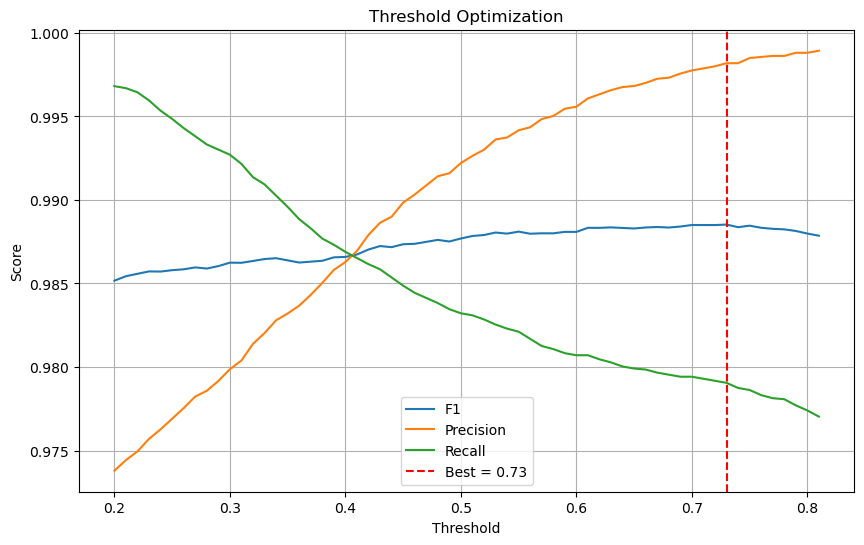

In [173]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    label=f"Best = {best_threshold:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")

plt.legend()

plt.grid(True)

plt.show()

In [174]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(30)

,Feature,Importance
81,CityRoute_Freq,0.238820
80,Route_Freq,0.128527
77,DepartureLocationCity_Freq,0.110354
75,RouteFrequency,0.087819
1,ShippingType,0.084222
2,ShippingTypeDescription,0.072084
76,DepartureLocationCountry_Freq,0.063689
68,IsInternational,0.062984
78,ArrivalLocationCountry_Freq,0.035184
34,Take Departure Train,0.018242


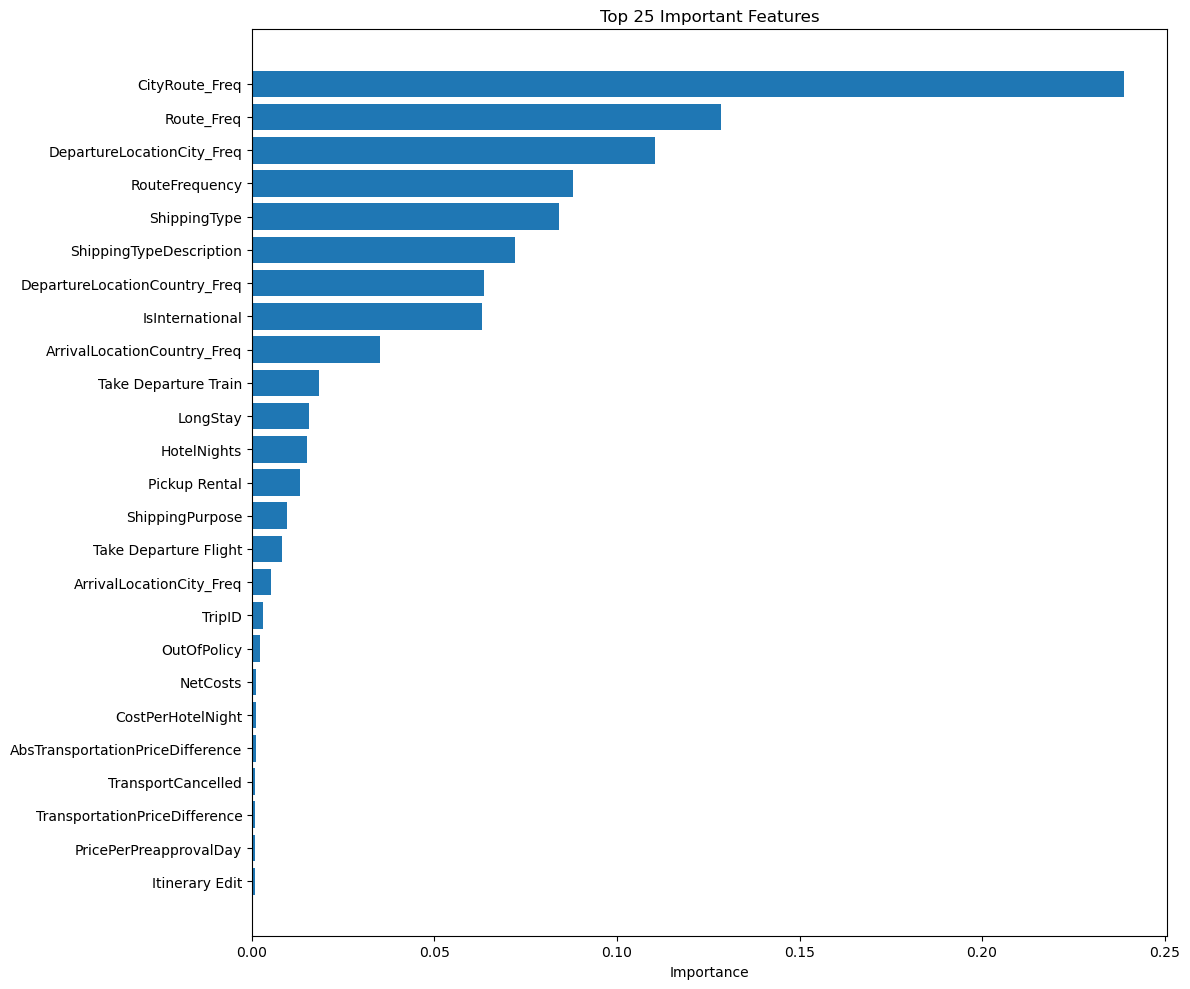

In [175]:
plt.figure(figsize=(12,10))

top = importance.head(25)

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 25 Important Features")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

In [176]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


In [177]:
submission = sample_submission.copy()

submission["HighCarbon"] = ensemble_test

submission.head()

,TripID,HighCarbon
0,2,0.998293
1,4,0.002159
2,5,0.988114
3,14,0.000454
4,15,0.000357


In [178]:
submission.to_csv(
    "submission.csv",
    index=False
)

print("Submission file created successfully!")

print(submission.head())

Submission file created successfully!
   TripID  HighCarbon
0       2    0.998293
1       4    0.002159
2       5    0.988114
3      14    0.000454
4      15    0.000357


In [179]:
print("Minimum probability :", submission["HighCarbon"].min())

print("Maximum probability :", submission["HighCarbon"].max())

print("Mean probability :", submission["HighCarbon"].mean())

Minimum probability : 0.00026430001881729676
Maximum probability : 0.9992517765178177
Mean probability : 0.2486648525985327


In [180]:
assert len(submission) == len(test_df)

assert submission["HighCarbon"].between(0,1).all()

print("Submission Verified Successfully")

print(submission.shape)

Submission Verified Successfully
(21764, 2)
